
# FX Algorithmic Execution Validation: TWAP vs VWAP

## Objective

The goal is to validate whether **TWAP** and **VWAP** execution strategies behave reasonably under different market conditions by using:

- simulated FX prices
- simulated intraday volume and liquidity
- bid-ask spread assumptions
- benchmark comparisons
- slippage and implementation shortfall metrics
- sensitivity analysis
- stress testing



In [47]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# random
np.random.seed(42)
market_df = simulate_fx_market()

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")



## 1. Simulate an intraday FX market environment

simulate a stylised FX market using four ingredients:

1. **Mid price path** driven by simulated log returns.
2. **Volume profile** with a U-shape pattern, which is common in intraday trading activity.
3. **Bid-ask spread**, representing an explicit transaction cost.
4. **Liquidity scaling**, which allows us to stress-test low-liquidity regimes.

### Modelling choices

- Log returns are used because they are additive over time and are commonly used in quantitative modelling.
- A U-shaped volume curve is used to mimic higher activity near the beginning and end of the trading session.
- Spread can widen under stress to reflect poorer execution conditions.


In [50]:

def simulate_fx_market(
    n_minutes=60,
    start_price=1.1000,
    sigma=0.0002,
    total_market_volume=1_000_000,
    base_spread_bps=1.0,
    liquidity_scale=1.0,
    trend_per_minute=0.0,
):
    """
    Simulate a simplified intraday FX market.

    Parameters
    ----------
    n_minutes : int
        Number of execution intervals.
    start_price : float
        Initial FX mid price.
    sigma : float
        Standard deviation of log returns; used as a volatility proxy.
    total_market_volume : int
        Total simulated market volume over the execution horizon.
    base_spread_bps : float
        Bid-ask spread in basis points.
    liquidity_scale : float
        Scaling factor for market liquidity. Values below 1 imply less liquidity.
    trend_per_minute : float
        Optional drift in log returns to create trending markets.

    Returns
    -------
    DataFrame
        Market data with mid, bid, ask, spread, and interval volume.
    """

    # Simulate log returns from a normal distribution.
    # This is a standard simplifying assumption in market simulation.
    log_returns = np.random.normal(loc=trend_per_minute, scale=sigma, size=n_minutes)  

    # Convert cumulative log returns into a price path (discrete-time GBM approximation)..
    prices = start_price * np.exp(np.cumsum(log_returns)) 

    # Generate a stylised U-shaped intraday volume pattern.
    x = np.linspace(-1, 1, n_minutes)
    volume_profile = x**2 + 0.5
    raw_volumes = total_market_volume * (volume_profile / volume_profile.sum())

    # Apply liquidity scaling. Lower liquidity means fewer units available to trade.
    volumes = raw_volumes * liquidity_scale

    # Convert spread from basis points into price units.
    spread = prices * (base_spread_bps / 10_000)

    # Build bid and ask quotes around the mid price.
    bid = prices - spread / 2
    ask = prices + spread / 2

    return pd.DataFrame({
        "minute": np.arange(1, n_minutes + 1),
        "mid_price": prices,
        "bid": bid,
        "ask": ask,
        "spread": spread,
        "market_volume": volumes,
        "log_return": log_returns,
    })


market_df = simulate_fx_market()
market_df.head(10)


,minute,mid_price,bid,ask,spread,market_volume,log_return
0,1,1.099895,1.099840,1.099950,0.000110,"29,598.662207",-0.000096
1,2,1.099854,1.099799,1.099909,0.000110,"28,283.544017",-0.000037
2,3,1.099610,1.099555,1.099665,0.000110,"27,013.774729",-0.000221
3,4,1.099347,1.099292,1.099402,0.000110,"25,789.354345",-0.000239
4,5,1.099526,1.099471,1.099581,0.000110,"24,610.282864",0.000163
5,6,1.099824,1.099769,1.099879,0.000110,"23,476.560286",0.000271
6,7,1.099808,1.099753,1.099863,0.000110,"22,388.186611",-0.000014
7,8,1.100029,1.099974,1.100084,0.000110,"21,345.161839",0.000201
8,9,1.100109,1.100054,1.100164,0.000110,"20,347.485970",0.000072
9,10,1.099967,1.099912,1.100022,0.000110,"19,395.159005",-0.000129



## 2. Visualise the simulated market

The plots below help explain the market assumptions used in the validation framework.


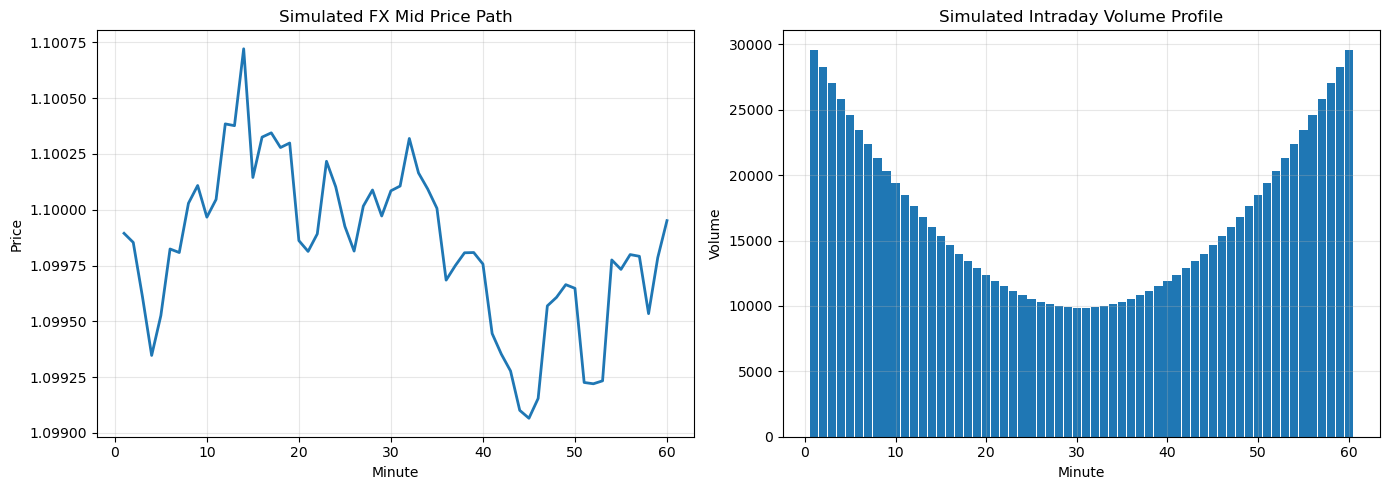

In [53]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(market_df["minute"], market_df["mid_price"], lw=2)
axes[0].set_title("Simulated FX Mid Price Path")
axes[0].set_xlabel("Minute")
axes[0].set_ylabel("Price")
axes[0].grid(True, alpha=0.3)

axes[1].bar(market_df["minute"], market_df["market_volume"], width=0.9)
axes[1].set_title("Simulated Intraday Volume Profile")
axes[1].set_xlabel("Minute")
axes[1].set_ylabel("Volume")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [55]:
# simulate:
# price path
# liquidity
# bid/ask
# spread
# 
# 
# 


## 3. Define execution strategies and validation metrics

We implement three execution approaches:

1. **TWAP**: evenly splits the order through time.
2. **VWAP**: allocates more volume to time buckets with higher market volume.
3. **Naive benchmark**: trades the full order immediately at the first available ask price.

The naive benchmark is intentionally simple. It gives us a reference point and helps illustrate why execution algorithms exist.

### Validation metrics

- **Average execution price**
- **Slippage vs arrival mid**
- **Implementation shortfall**
- **Comparison to market VWAP**


In [58]:
# time equal size
def execute_twap(market_df, order_size):
    """Execute a buy order evenly through time."""
    df = market_df.copy()
    n = len(df)
    qty = np.full(n, order_size / n)

    # a buy order, we will pays the ask.
    exec_price = df["ask"].values

    df["strategy"] = "TWAP"
    df["qty"] = qty
    df["exec_price"] = exec_price 
    return df
twap_df = execute_twap(market_df, order_size=1000)
twap_df.head(10)

,minute,mid_price,bid,ask,spread,market_volume,log_return,strategy,qty,exec_price
0,1,1.099895,1.099840,1.099950,0.000110,"29,598.662207",-0.000096,TWAP,16.666667,1.099950
1,2,1.099854,1.099799,1.099909,0.000110,"28,283.544017",-0.000037,TWAP,16.666667,1.099909
2,3,1.099610,1.099555,1.099665,0.000110,"27,013.774729",-0.000221,TWAP,16.666667,1.099665
3,4,1.099347,1.099292,1.099402,0.000110,"25,789.354345",-0.000239,TWAP,16.666667,1.099402
4,5,1.099526,1.099471,1.099581,0.000110,"24,610.282864",0.000163,TWAP,16.666667,1.099581
5,6,1.099824,1.099769,1.099879,0.000110,"23,476.560286",0.000271,TWAP,16.666667,1.099879
6,7,1.099808,1.099753,1.099863,0.000110,"22,388.186611",-0.000014,TWAP,16.666667,1.099863
7,8,1.100029,1.099974,1.100084,0.000110,"21,345.161839",0.000201,TWAP,16.666667,1.100084
8,9,1.100109,1.100054,1.100164,0.000110,"20,347.485970",0.000072,TWAP,16.666667,1.100164
9,10,1.099967,1.099912,1.100022,0.000110,"19,395.159005",-0.000129,TWAP,16.666667,1.100022


In [60]:
# based on market vloume

def execute_vwap(market_df, order_size):
    """Execute a buy order in proportion to market volume."""
    df = market_df.copy()
    volume_weights = df["market_volume"] / df["market_volume"].sum()
    qty = order_size * volume_weights.values
    exec_price = df["ask"].values

    df["strategy"] = "VWAP"
    df["qty"] = qty
    df["exec_price"] = exec_price
    return df
vwap_df = execute_vwap(market_df, order_size=1000)

vwap_df.head(10)

,minute,mid_price,bid,ask,spread,market_volume,log_return,strategy,qty,exec_price
0,1,1.099895,1.099840,1.099950,0.000110,"29,598.662207",-0.000096,VWAP,29.598662,1.099950
1,2,1.099854,1.099799,1.099909,0.000110,"28,283.544017",-0.000037,VWAP,28.283544,1.099909
2,3,1.099610,1.099555,1.099665,0.000110,"27,013.774729",-0.000221,VWAP,27.013775,1.099665
3,4,1.099347,1.099292,1.099402,0.000110,"25,789.354345",-0.000239,VWAP,25.789354,1.099402
4,5,1.099526,1.099471,1.099581,0.000110,"24,610.282864",0.000163,VWAP,24.610283,1.099581
5,6,1.099824,1.099769,1.099879,0.000110,"23,476.560286",0.000271,VWAP,23.476560,1.099879
6,7,1.099808,1.099753,1.099863,0.000110,"22,388.186611",-0.000014,VWAP,22.388187,1.099863
7,8,1.100029,1.099974,1.100084,0.000110,"21,345.161839",0.000201,VWAP,21.345162,1.100084
8,9,1.100109,1.100054,1.100164,0.000110,"20,347.485970",0.000072,VWAP,20.347486,1.100164
9,10,1.099967,1.099912,1.100022,0.000110,"19,395.159005",-0.000129,VWAP,19.395159,1.100022


In [62]:
# our base/benchmark
# oder one time, all in


def execute_naive_arrival(market_df, order_size):
    """Naive benchmark: execute the full order immediately at the arrival ask."""
    df = market_df.copy()
    qty = np.zeros(len(df))
    qty[0] = order_size # all in
    exec_price = np.full(len(df), np.nan)
    exec_price[0] = df["ask"].iloc[0]  # asking price

    df["strategy"] = "NaiveArrival"
    df["qty"] = qty
    df["exec_price"] = exec_price
    return df

naive_df = execute_naive_arrival(market_df, order_size = 1000)

naive_df.head(10)


,minute,mid_price,bid,ask,spread,market_volume,log_return,strategy,qty,exec_price
0,1,1.099895,1.099840,1.099950,0.000110,"29,598.662207",-0.000096,NaiveArrival,"1,000.000000",1.099950
1,2,1.099854,1.099799,1.099909,0.000110,"28,283.544017",-0.000037,NaiveArrival,0.000000,NaN
2,3,1.099610,1.099555,1.099665,0.000110,"27,013.774729",-0.000221,NaiveArrival,0.000000,NaN
3,4,1.099347,1.099292,1.099402,0.000110,"25,789.354345",-0.000239,NaiveArrival,0.000000,NaN
4,5,1.099526,1.099471,1.099581,0.000110,"24,610.282864",0.000163,NaiveArrival,0.000000,NaN
5,6,1.099824,1.099769,1.099879,0.000110,"23,476.560286",0.000271,NaiveArrival,0.000000,NaN
6,7,1.099808,1.099753,1.099863,0.000110,"22,388.186611",-0.000014,NaiveArrival,0.000000,NaN
7,8,1.100029,1.099974,1.100084,0.000110,"21,345.161839",0.000201,NaiveArrival,0.000000,NaN
8,9,1.100109,1.100054,1.100164,0.000110,"20,347.485970",0.000072,NaiveArrival,0.000000,NaN
9,10,1.099967,1.099912,1.100022,0.000110,"19,395.159005",-0.000129,NaiveArrival,0.000000,NaN


In [64]:
def avg_exec_price(df):
    traded = df[df["qty"] > 0]
    return (traded["qty"] * traded["exec_price"]).sum() / traded["qty"].sum()

print("Naive:", avg_exec_price(naive_df))
print("TWAP:", avg_exec_price(twap_df))
print("VWAP:", avg_exec_price(vwap_df))

Naive: 1.0999495814482236
TWAP: 1.0998903362516121
VWAP: 1.099859448541571


In [66]:

def evaluate_execution(execution_df, market_df, order_size):
    """Compute execution quality metrics for a buy order."""
    traded = execution_df[execution_df["qty"] > 0].copy()
    avg_exec_price = np.sum(traded["qty"] * traded["exec_price"]) / order_size

    arrival_mid = market_df["mid_price"].iloc[0]   # the benchmark price at order arrival
    market_vwap = np.sum(market_df["mid_price"] * market_df["market_volume"]) / market_df["market_volume"].sum()  # volume-weighted market average price

    # Slippage vs arrival mid in price terms and in basis points.
    slippage = avg_exec_price - arrival_mid
    slippage_bps = (slippage / arrival_mid) * 10_000   # how much higher than expected price

    # Implementation shortfall for a buy order uses arrival mid as the reference.
    implementation_shortfall = (avg_exec_price - arrival_mid) * order_size  #(execution cost-  bench mark)* order_size

    # Compare execution to market VWAP as an additional benchmark.
    vs_market_vwap_bps = ((avg_exec_price - market_vwap) / market_vwap) * 10_000  # better or worse than market

    return {
        "strategy": execution_df["strategy"].iloc[0],
        "order_size": order_size,
        "avg_exec_price": avg_exec_price,
        "arrival_mid": arrival_mid,
        "market_vwap": market_vwap,
        "slippage_bps": slippage_bps,
        "implementation_shortfall": implementation_shortfall,
        "vs_market_vwap_bps": vs_market_vwap_bps,
    }



results = [
    evaluate_execution(naive_df, market_df, 1000),
    evaluate_execution(twap_df, market_df, 1000),
    evaluate_execution(vwap_df, market_df, 1000),
]


results_df = pd.DataFrame(results)
results_df

,strategy,order_size,avg_exec_price,arrival_mid,market_vwap,slippage_bps,implementation_shortfall,vs_market_vwap_bps
0,NaiveArrival,1000,1.099950,1.099895,1.099804,0.500000,0.054995,1.319536
1,TWAP,1000,1.099890,1.099895,1.099804,-0.038644,-0.004250,0.780847
2,VWAP,1000,1.099859,1.099895,1.099804,-0.319469,-0.035138,0.500000


In [68]:
# naive best : average_exe_price = 1.100013
# then the vwap 1.
# the twap worst 1.10
# as market is increasing, the earier the better
#This shows that execution performance depends heavily on market conditions.
# cheaper than market -16.5,,,, higher than market 


## 4. Base-case validation

We first compare TWAP and VWAP under a base-case market environment.


In [71]:

order_size = 100_000

strategies = [
    execute_twap(market_df, order_size),
    execute_vwap(market_df, order_size),
    execute_naive_arrival(market_df, order_size),
]

base_results = pd.DataFrame([evaluate_execution(s, market_df, order_size) for s in strategies])
base_results


,strategy,order_size,avg_exec_price,arrival_mid,market_vwap,slippage_bps,implementation_shortfall,vs_market_vwap_bps
0,TWAP,100000,1.099890,1.099895,1.099804,-0.038644,-0.425047,0.780847
1,VWAP,100000,1.099859,1.099895,1.099804,-0.319469,-3.513818,0.500000
2,NaiveArrival,100000,1.099950,1.099895,1.099804,0.500000,5.499473,1.319536



## 5. Interpretation of the base case


- The market exhibits a **downward trend**, as execution prices are generally lower than the arrival price.
- - Under these conditions:
  - **VWAP performs best**, achieving the lowest slippage.
  - **TWAP performs well**, but slightly worse than VWAP.
  - **Naive execution performs worst**, as it executes the entire order immediately at higher prices.



This result highlights that, in a declining market, spreading execution over time allows the trader to benefit from progressively lower prices.

Furthermore, as the order size increases, the differences in execution cost become more pronounced. This demonstrates that execution strategy selection becomes increasingly important for larger orders.

Overall, the findings confirm that execution performance is highly dependent on both market conditions and order size.





## 6. Benchmark and challenger comparison

we compare:

- **TWAP**
- **VWAP**
- **Naive benchmark**

The purpose is not only to rank strategies, but also to identify **where execution performance deteriorates**.


In [75]:

comparison = base_results[[
    "strategy",
    "avg_exec_price",
    "slippage_bps",
    "implementation_shortfall",
    "vs_market_vwap_bps",
]].sort_values("slippage_bps")

comparison


,strategy,avg_exec_price,slippage_bps,implementation_shortfall,vs_market_vwap_bps
1,VWAP,1.099859,-0.319469,-3.513818,0.500000
0,TWAP,1.099890,-0.038644,-0.425047,0.780847
2,NaiveArrival,1.099950,0.500000,5.499473,1.319536



### Interpretation

If TWAP and VWAP materially outperform the naive benchmark, this supports the intuition that execution algorithms reduce execution cost.
If one strategy deteriorates more than the other under stress, that gives a validation angle for discussing **execution inefficiencies** and **model limitations**.




## 7. Sensitivity analysis

We now vary key parameters:

- **order size**
- **execution horizon**
- **liquidity levels**
- **spread assumptions**

This is a core model validation step because a good execution strategy should not only work in one setting.


In [79]:

def run_validation_scenario(
    order_size=100_000,
    n_minutes=60,
    sigma=0.0002,
    total_market_volume=1_000_000,
    base_spread_bps=1.0,
    liquidity_scale=1.0,
    trend_per_minute=0.0,
):
    market = simulate_fx_market(
        n_minutes=n_minutes,
        sigma=sigma,
        total_market_volume=total_market_volume,
        base_spread_bps=base_spread_bps,
        liquidity_scale=liquidity_scale,
        trend_per_minute=trend_per_minute,
    )
    twap = evaluate_execution(execute_twap(market, order_size), market, order_size)
    vwap = evaluate_execution(execute_vwap(market, order_size), market, order_size)
    return pd.DataFrame([twap, vwap])


sensitivity_results = []

# 1) Order size sensitivity
for size in [50_000, 100_000, 250_000, 500_000]:
    df = run_validation_scenario(order_size=size)
    df["test_type"] = "Order Size"
    df["test_value"] = size
    sensitivity_results.append(df)

# 2) Execution horizon sensitivity
for horizon in [30, 60, 120]:
    df = run_validation_scenario(order_size=100_000, n_minutes=horizon)
    df["test_type"] = "Execution Horizon"
    df["test_value"] = horizon
    sensitivity_results.append(df)

# 3) Liquidity sensitivity
for liq in [0.5, 1.0, 1.5]:
    df = run_validation_scenario(order_size=100_000, liquidity_scale=liq)
    df["test_type"] = "Liquidity Scale"
    df["test_value"] = liq
    sensitivity_results.append(df)

# 4) Spread sensitivity
for spread_bps in [1.0, 3.0, 5.0]:
    df = run_validation_scenario(order_size=100_000, base_spread_bps=spread_bps)
    df["test_type"] = "Spread (bps)"
    df["test_value"] = spread_bps
    sensitivity_results.append(df)

sensitivity_df = pd.concat(sensitivity_results, ignore_index=True)
sensitivity_df.head(12)


,strategy,order_size,avg_exec_price,arrival_mid,market_vwap,slippage_bps,implementation_shortfall,vs_market_vwap_bps,test_type,test_value
0,TWAP,50000,1.099952,1.100174,1.100021,-2.014196,-11.079831,-0.623596,Order Size,"50,000.000000"
1,VWAP,50000,1.100076,1.100174,1.100021,-0.890756,-4.899932,0.500000,Order Size,"50,000.000000"
2,TWAP,100000,1.100293,1.100138,1.100246,1.409068,15.501684,0.420778,Order Size,"100,000.000000"
3,VWAP,100000,1.100301,1.100138,1.100246,1.488298,16.373326,0.500000,Order Size,"100,000.000000"
4,TWAP,250000,1.099639,1.099826,1.099615,-1.694191,-46.582862,0.224842,Order Size,"250,000.000000"
5,VWAP,250000,1.099670,1.099826,1.099615,-1.419086,-39.018677,0.500000,Order Size,"250,000.000000"
6,TWAP,500000,1.101002,1.099818,1.100767,10.773262,592.431183,2.142379,Order Size,"500,000.000000"
7,VWAP,500000,1.100822,1.099818,1.100767,9.129466,502.037367,0.500000,Order Size,"500,000.000000"
8,TWAP,100000,1.101117,1.100114,1.100994,9.112235,100.244996,1.114315,Execution Horizon,30.000000
9,VWAP,100000,1.101049,1.100114,1.100994,8.497429,93.481427,0.500000,Execution Horizon,30.000000



## 8. Visualise sensitivity results


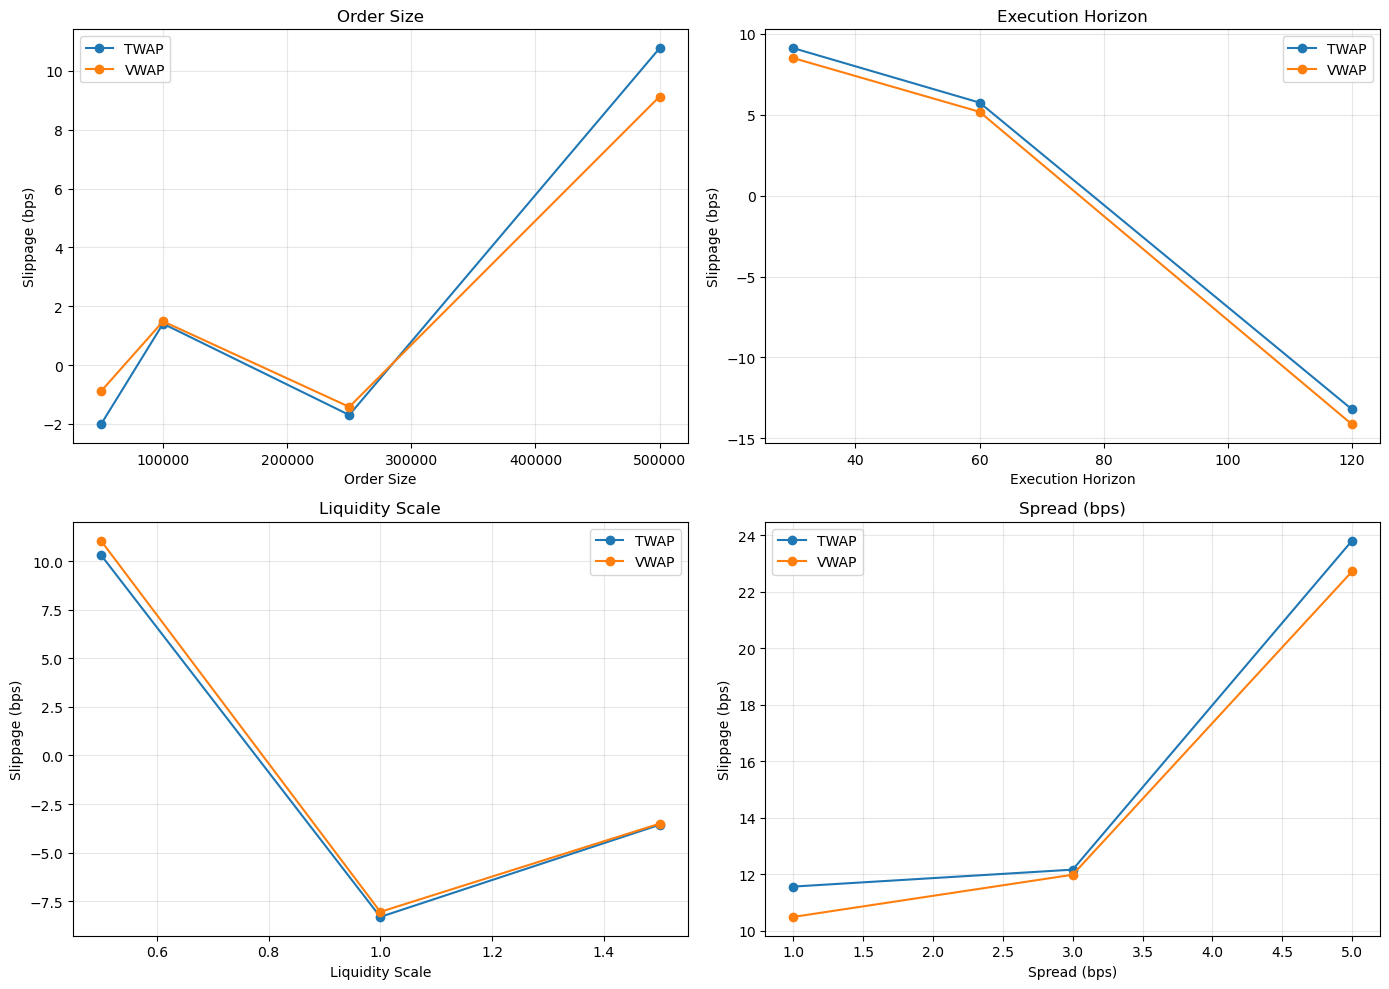

In [82]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
plot_tests = ["Order Size", "Execution Horizon", "Liquidity Scale", "Spread (bps)"]

for ax, test in zip(axes, plot_tests):
    subset = sensitivity_df[sensitivity_df["test_type"] == test]
    for strategy in ["TWAP", "VWAP"]:
        s = subset[subset["strategy"] == strategy]
        ax.plot(s["test_value"], s["slippage_bps"], marker="o", label=strategy)
    ax.set_title(test)
    ax.set_xlabel(test)
    ax.set_ylabel("Slippage (bps)")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()



## 9. Stress testing

We create stressed scenarios that are more adverse than the base case. This is different from sensitivity analysis:

- **Sensitivity analysis** changes one assumption at a time.
- **Stress testing** combines severe assumptions to challenge robustness.

We consider three stressed regimes:

1. **High volatility**
2. **Low liquidity**
3. **Combined stress**: high volatility + low liquidity + wider spreads


In [88]:

stress_scenarios = {
    "Base": {
        "sigma": 0.0002,
        "liquidity_scale": 1.0,
        "base_spread_bps": 1.0,
    },
    "High Volatility": {
        "sigma": 0.0008,
        "liquidity_scale": 1.0,
        "base_spread_bps": 1.0,
    },
    "Low Liquidity": {
        "sigma": 0.0002,
        "liquidity_scale": 0.4,
        "base_spread_bps": 1.0,
    },
    "Combined Stress": {
        "sigma": 0.0008,
        "liquidity_scale": 0.4,
        "base_spread_bps": 4.0,
    },
}

stress_results = []
for scenario_name, params in stress_scenarios.items():
    df = run_validation_scenario(order_size=100_000, **params)
    df["scenario"] = scenario_name
    stress_results.append(df)

stress_df = pd.concat(stress_results, ignore_index=True)
stress_df


,strategy,order_size,avg_exec_price,arrival_mid,market_vwap,slippage_bps,implementation_shortfall,vs_market_vwap_bps,scenario
0,TWAP,100000,1.099747,1.099878,1.099635,-1.187889,-13.065327,1.020178,Base
1,VWAP,100000,1.099690,1.099878,1.099635,-1.707952,-18.785387,0.500000,Base
2,TWAP,100000,1.105679,1.100183,1.105293,49.953104,549.575759,3.493108,High Volatility
3,VWAP,100000,1.105348,1.100183,1.105293,46.946095,516.493141,0.500000,High Volatility
4,TWAP,100000,1.099701,1.099862,1.099749,-1.463633,-16.097946,-0.430856,Low Liquidity
5,VWAP,100000,1.099804,1.099862,1.099749,-0.532873,-5.860874,0.500000,Low Liquidity
6,TWAP,100000,1.108133,1.099832,1.107376,75.473260,830.079225,6.837766,Combined Stress
7,VWAP,100000,1.107597,1.099832,1.107376,70.602312,776.506972,2.000000,Combined Stress


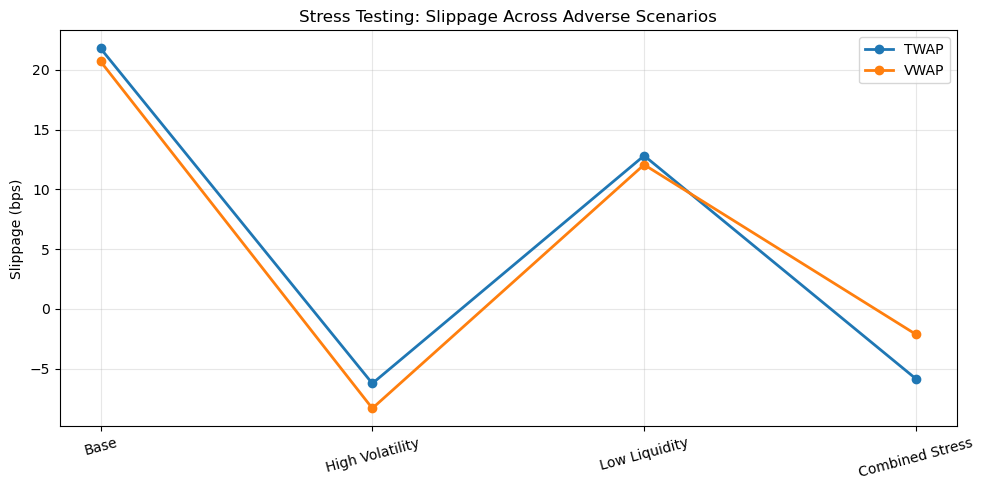

In [43]:

fig, ax = plt.subplots(figsize=(10, 5))
for strategy in ["TWAP", "VWAP"]:
    s = stress_df[stress_df["strategy"] == strategy]
    ax.plot(s["scenario"], s["slippage_bps"], marker="o", linewidth=2, label=strategy)

ax.set_title("Stress Testing: Slippage Across Adverse Scenarios")
ax.set_ylabel("Slippage (bps)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



## 10. Validation conclusions and model limitations

### Example conclusions

- TWAP is simple and stable, but it does not adapt to realised market volume.
- VWAP is more market-aware, but depends on the quality of the volume profile.
- Execution quality deteriorates under lower liquidity, wider spreads, and higher volatility.
- Benchmark comparison and stress testing are necessary to judge whether a strategy is fit for purpose.

### Model limitations

This example is intentionally simplified. Important limitations include:

- no explicit market impact model
- no dynamic order book simulation
- no latency effects
- no transaction cost decomposition beyond spread / slippage metrics
- simulated rather than real market data


